# Modelado y Proyección de Costos

1. Cargar variables seleccionadas en notebook_2
2. Entrenar modelo OLS final con validación cruzada temporal
3. Proyectar materias primas con ARIMA
4. Proyectar equipos con propagación de incertidumbre
5. Exportar resultados a `results/forecasts.json`

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

try:
    import pmdarima as pm
    HAS_PMDARIMA = True
except ImportError:
    HAS_PMDARIMA = False
    print("pmdarima no instalado — usando ARIMA manual")

from src.data_loader import build_analysis_dataset, build_extended_series

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='whitegrid')

RESULTS_DIR = '../results/figures'
os.makedirs(RESULTS_DIR, exist_ok=True)

## 1. Cargar datos y variables seleccionadas

In [2]:
df = build_analysis_dataset()
df = df.set_index('Date')

# Cargar variables seleccionadas del notebook anterior
selected_features_path = '../results/selected_features.json'
if os.path.exists(selected_features_path):
    with open(selected_features_path) as f:
        selected_features = json.load(f)
    print("Variables seleccionadas cargadas:")
    print(json.dumps(selected_features, indent=2))
else:
    # Fallback: usar todas las variables (se determinará tras ejecutar notebook 02)
    selected_features = {
        'Price_Equipo1': ['Price_X', 'Price_Y', 'Price_Z'],
        'Price_Equipo2': ['Price_X', 'Price_Y', 'Price_Z'],
    }
    print("Archivo selected_features.json no encontrado. Ejecuta primero el notebook 02.")
    print("Usando todas las variables como fallback.")

Variables seleccionadas cargadas:
{
  "Price_Equipo1": [
    "Price_X",
    "Price_Y"
  ],
  "Price_Equipo2": [
    "Price_X",
    "Price_Y",
    "Price_Z"
  ]
}


## 2. Validación cruzada temporal (TimeSeriesSplit)

In [3]:
def evaluate_ols_cv(df, features, target, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    X = df[features].values
    y = df[target].values
    
    maes, rmses, r2s = [], [], []
    
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        X_train_ols = sm.add_constant(X_train)
        X_test_ols = sm.add_constant(X_test)
        
        model = sm.OLS(y_train, X_train_ols).fit()
        y_pred = model.predict(X_test_ols)
        
        maes.append(mean_absolute_error(y_test, y_pred))
        rmses.append(np.sqrt(mean_squared_error(y_test, y_pred)))
        r2s.append(r2_score(y_test, y_pred))
    
    return {
        'MAE': np.mean(maes),
        'RMSE': np.mean(rmses),
        'R²': np.mean(r2s),
        'MAE std': np.std(maes),
    }

cv_results = {}
for target, feats in selected_features.items():
    if not feats:
        print(f"{target}: sin features seleccionadas")
        continue
    metrics = evaluate_ols_cv(df, feats, target)
    cv_results[target] = metrics
    print(f"\n{target}:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")


Price_Equipo1:
  MAE: 6.7303
  RMSE: 7.8771
  R²: 0.9758
  MAE std: 1.3015

Price_Equipo2:
  MAE: 12.9818
  RMSE: 15.1246
  R²: 0.9649
  MAE std: 2.0904


En general el modelo funciona bien, errores del 1.5% son pequeños para la planeacion financiera,


## 3. Modelo final OLS — Entrenamiento sobre el dataset completo

In [4]:
final_models = {}

for target, feats in selected_features.items():
    if not feats:
        continue
    X_ols = sm.add_constant(df[feats])
    y_ols = df[target]
    model = sm.OLS(y_ols, X_ols).fit()
    final_models[target] = model
    
    print(f"\n{'='*60}")
    print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          Price_Equipo1   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 3.320e+05
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:08:09   Log-Likelihood:                -12463.
No. Observations:                3530   AIC:                         2.493e+04
Df Residuals:                    3527   BIC:                         2.495e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0824      0.603     -0.137      0.

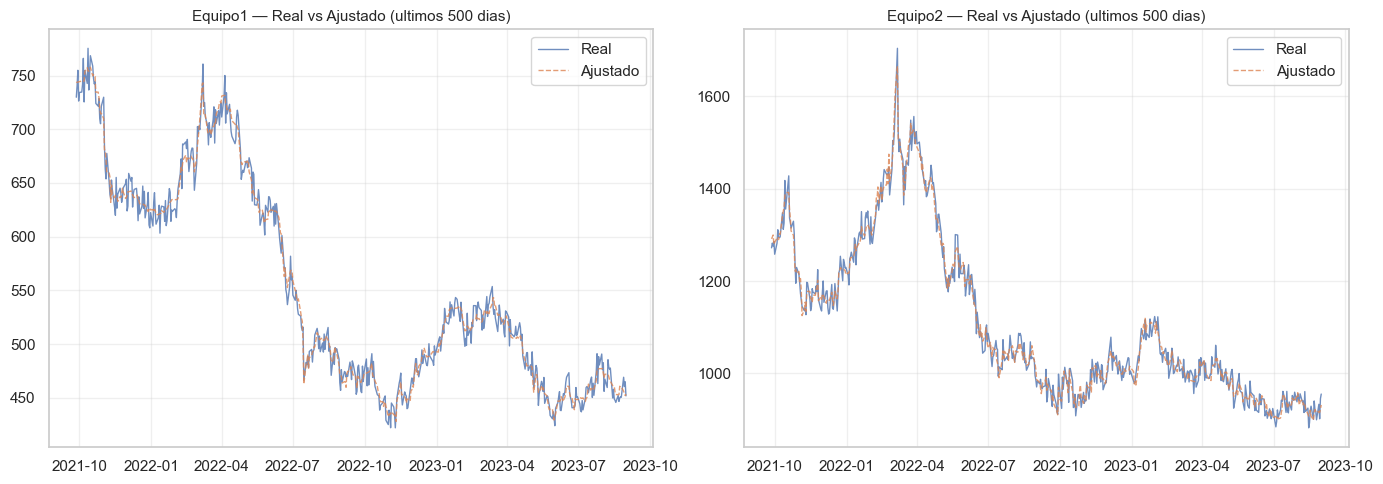

In [5]:
# Gráfica fitted vs actual
fig, axes = plt.subplots(1, len(final_models), figsize=(14, 5))
if len(final_models) == 1:
    axes = [axes]

for ax, (target, model) in zip(axes, final_models.items()):
    feats = selected_features[target]
    X_ols = sm.add_constant(df[feats])
    fitted = model.predict(X_ols)
    
    ax.plot(df.index[-500:], df[target].values[-500:], label='Real', alpha=0.8, linewidth=1)
    ax.plot(df.index[-500:], fitted.values[-500:], label='Ajustado', alpha=0.8, linewidth=1, linestyle='--')
    ax.set_title(f'{target.replace("Price_","")} — Real vs Ajustado (ultimos 500 dias)', fontsize=11)
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/08_fitted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

## 3b. Validaciones del modelo OLS

Tres pruebas para confirmar que la regresión sobre series de tiempo no es espuria.

In [6]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.stats.diagnostic import acorr_ljungbox

# ── 1. Test de Johansen ───────────────────────────────────────────────────────
johansen_configs = {
    'Price_Equipo1': ['Price_Equipo1', 'Price_X', 'Price_Y'],
    'Price_Equipo2': ['Price_Equipo2', 'Price_X', 'Price_Y', 'Price_Z'],
}

for equipo, cols in johansen_configs.items():
    data_j = df[cols].dropna()
    result = coint_johansen(data_j, det_order=0, k_ar_diff=1)

    print(f"\n{equipo} ~ {cols[1:]}")
    print(f"  {'Hipotesis':<20} {'Estadistico':>14} {'Val. critico 5%':>16} {'Rechaza H0':>12}")
    print(f"  {'-'*64}")
    labels = [f"r <= {i}" for i in range(len(cols))]
    for i, label in enumerate(labels):
        stat    = result.lr1[i]
        cv_5pct = result.cvt[i, 1]
        rechaza = "SI" if stat > cv_5pct else "NO"
        print(f"  {label:<20} {stat:>14.2f} {cv_5pct:>16.2f} {rechaza:>12}")


Price_Equipo1 ~ ['Price_X', 'Price_Y']
  Hipotesis               Estadistico  Val. critico 5%   Rechaza H0
  ----------------------------------------------------------------
  r <= 0                      1430.59            29.80           SI
  r <= 1                        19.22            15.49           SI
  r <= 2                         5.12             3.84           SI

Price_Equipo2 ~ ['Price_X', 'Price_Y', 'Price_Z']
  Hipotesis               Estadistico  Val. critico 5%   Rechaza H0
  ----------------------------------------------------------------
  r <= 0                      1575.30            47.85           SI
  r <= 1                        40.97            29.80           SI
  r <= 2                        19.48            15.49           SI
  r <= 3                         6.00             3.84           SI


Ambos equipos rechazan la hipótesis nula en todos los rangos. Las series comparten un equilibrio de largo plazo. El OLS no está capturando una correlación espuria.

Los p-valores de Ljung-Box confirman que los residuos no tienen autocorrelación estructural. En el rolling OLS, los coeficientes de Price_Y y Price_Z se mantienen estables en todo el período; Price_X muestra algo más de variabilidad en ventanas cortas pero sin romper la relación.

Price_Equipo1:
  Lag         Estadistico      p-valor   Ruido blanco
  lag=10             5.74       0.8369             SI
  lag=20            14.01       0.8300             SI
  lag=40            39.30       0.5016             SI

Price_Equipo2:
  Lag         Estadistico      p-valor   Ruido blanco
  lag=10            16.69       0.0816             SI
  lag=20            26.66       0.1452             SI
  lag=40            47.10       0.2047             SI



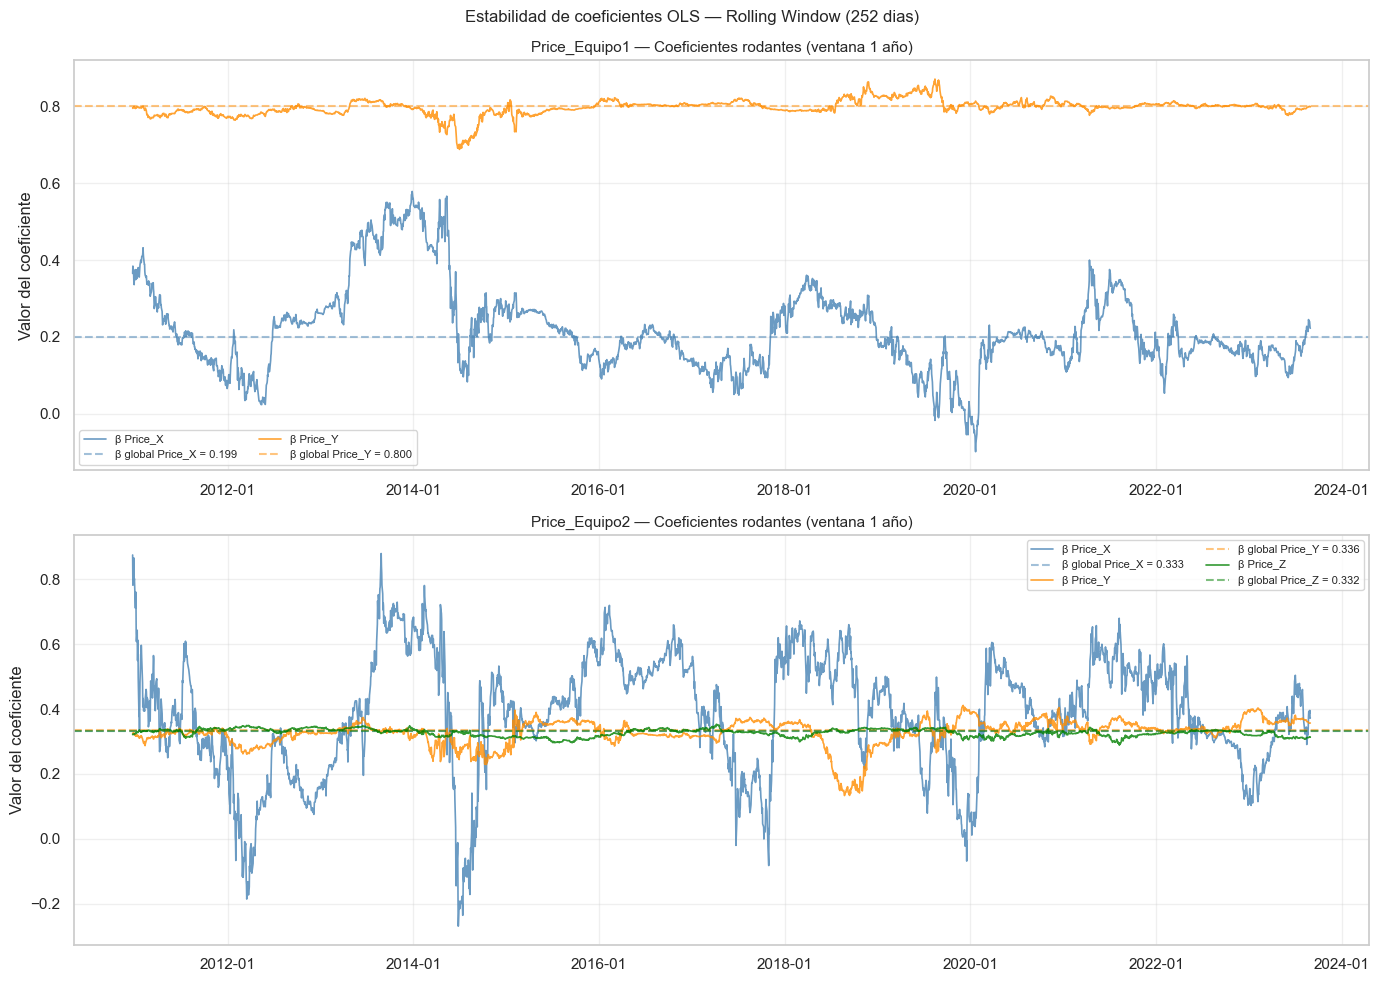

In [7]:
# ── 2. Ljung-Box sobre residuos del OLS ──────────────────────────────────────
for target, model in final_models.items():
    resid = model.resid
    lb = acorr_ljungbox(resid, lags=[10, 20, 40], return_df=True)
    print(f"{target}:")
    print(f"  {'Lag':<8} {'Estadistico':>14} {'p-valor':>12} {'Ruido blanco':>14}")
    for lag, row in lb.iterrows():
        ruido = "SI" if row['lb_pvalue'] > 0.05 else "NO"
        print(f"  lag={lag:<4} {row['lb_stat']:>14.2f} {row['lb_pvalue']:>12.4f} {ruido:>14}")
    print()

# ── 3. Rolling OLS — estabilidad de coeficientes (ventana 1 año) ──────────────
ROLLING_WINDOW = 252
fig, axes = plt.subplots(len(final_models), 1, figsize=(14, 5 * len(final_models)))
if len(final_models) == 1:
    axes = [axes]

for ax, (target, global_model) in zip(axes, final_models.items()):
    feats = selected_features[target]
    rolling_records = []

    for i in range(ROLLING_WINDOW, len(df)):
        window = df.iloc[i - ROLLING_WINDOW:i]
        X_w = sm.add_constant(window[feats])
        y_w = window[target]
        m_w = sm.OLS(y_w, X_w).fit()
        rec = {'date': df.index[i]}
        rec.update(m_w.params.to_dict())
        rolling_records.append(rec)

    roll_df = pd.DataFrame(rolling_records).set_index('date')

    colors = ['steelblue', 'darkorange', 'green', 'red']
    for feat, color in zip(feats, colors):
        col = f'Price_{feat.split("_")[1]}' if 'Price_' not in feat else feat
        if col in roll_df.columns:
            ax.plot(roll_df.index, roll_df[col], label=f'β {col}',
                    linewidth=1.2, color=color, alpha=0.8)
            global_beta = global_model.params[col]
            ax.axhline(global_beta, linestyle='--', color=color, alpha=0.5,
                       label=f'β global {col} = {global_beta:.3f}')

    ax.set_title(f'{target} — Coeficientes rodantes (ventana 1 año)', fontsize=11)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.set_ylabel('Valor del coeficiente')

plt.suptitle('Estabilidad de coeficientes OLS — Rolling Window (252 dias)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/08b_rolling_ols.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Proyección de materias primas

Horizonte de 6 meses (~126 días hábiles) desde el último dato disponible (agosto 2023). Se comparan ARIMA y Holt Lineal Trend sobre los últimos 3 meses de test; el modelo con menor RMSE se usa para la proyección final.

El ganador por serie aparece en el título de cada gráfica. El diagnóstico de drift a continuación verifica que el modelo seleccionado capture la dirección de la tendencia reciente, no solo el nivel.

In [8]:
FORECAST_STEPS = 126  # ~6 meses de días hábiles
ANALYSIS_END = pd.Timestamp('2023-08-31')  # último dato del dataset de equipos

# Series extendidas para mejor ajuste del ARIMA
extended_series = build_extended_series()

# Identificar qué materias primas necesitamos proyectar
needed_features = set()
for feats in selected_features.values():
    needed_features.update(feats)

print(f"Materias primas a proyectar: {needed_features}")
print(f"Horizonte: {FORECAST_STEPS} dias habiles (~6 meses)")
print(f"Inicio de proyeccion: {pd.bdate_range(start=ANALYSIS_END + pd.Timedelta(days=1), periods=1)[0].date()}")
print(f"Fin estimado de proyeccion: {pd.bdate_range(start=ANALYSIS_END + pd.Timedelta(days=1), periods=FORECAST_STEPS)[-1].date()}")

Materias primas a proyectar: {'Price_X', 'Price_Y', 'Price_Z'}
Horizonte: 126 dias habiles (~6 meses)
Inicio de proyeccion: 2023-09-01
Fin estimado de proyeccion: 2024-02-23



Price_X  |  train completo: 8927 obs  |  test: 63 obs
  Test: 2023-06-06 → 2023-08-31


c:\Users\marcela\Documents\pruebas_tecnicas\dataknow\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\marcela\Documents\pruebas_tecnicas\dataknow\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\marcela\Documents\pruebas_tecnicas\dataknow\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


  ARIMA(2, 1, 3):   RMSE=5.90  MAE=4.88
  Holt (2y window): RMSE=5.83  MAE=4.83
  => Ganador: Holt

Price_Y  |  train completo: 4414 obs  |  test: 63 obs
  Test: 2023-06-06 → 2023-08-31


c:\Users\marcela\Documents\pruebas_tecnicas\dataknow\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\marcela\Documents\pruebas_tecnicas\dataknow\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


  ARIMA(1, 1, 1):   RMSE=23.00  MAE=19.27
  Holt (2y window): RMSE=54.36  MAE=47.38
  => Ganador: ARIMA

Price_Z  |  train completo: 3502 obs  |  test: 63 obs
  Test: 2023-06-06 → 2023-08-31


c:\Users\marcela\Documents\pruebas_tecnicas\dataknow\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


  ARIMA(2, 1, 2):   RMSE=75.85  MAE=65.80
  Holt (2y window): RMSE=61.84  MAE=52.19
  => Ganador: Holt


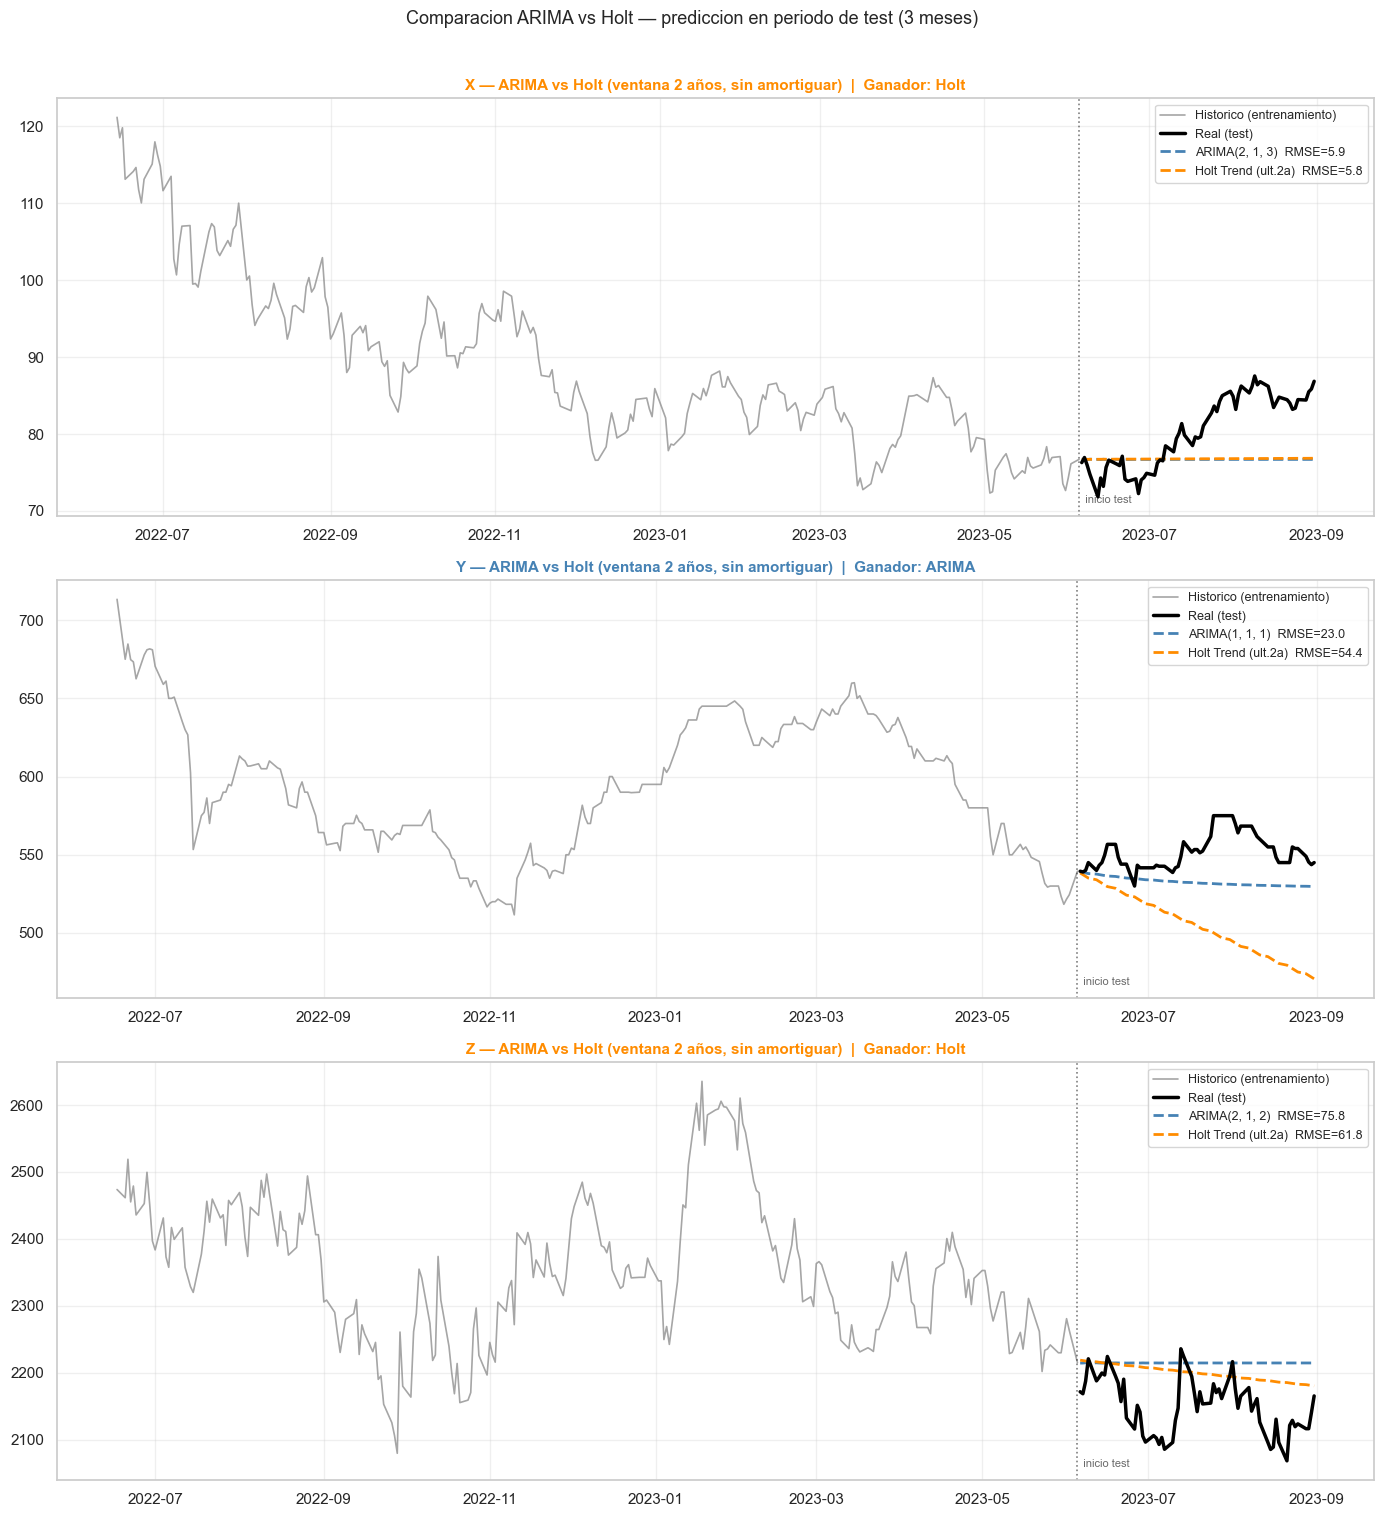

In [9]:
TEST_STEPS    = 63    # ~3 meses hábiles para evaluación
HOLT_WINDOW   = 504   # ~2 años de datos recientes para estimar tendencia actual
model_winners    = {}
comparison_results = {}

n_feats = len(needed_features)
fig, axes = plt.subplots(n_feats, 1, figsize=(14, 5 * n_feats))
if n_feats == 1:
    axes = [axes]

for ax, feat in zip(axes, sorted(needed_features)):
    mp_name = feat.replace('Price_', '')

    # ── Serie hasta ANALYSIS_END (sin data leakage) ──────────────────────
    if mp_name in extended_series:
        series_cut = extended_series[mp_name].set_index('Date')[feat]
        series_cut = series_cut[series_cut.index <= ANALYSIS_END]
    else:
        series_cut = df[feat]

    train = series_cut.iloc[:-TEST_STEPS]
    test  = series_cut.iloc[-TEST_STEPS:]

    print(f"\n{'='*55}")
    print(f"{feat}  |  train completo: {len(train)} obs  |  test: {len(test)} obs")
    print(f"  Test: {test.index[0].date()} → {test.index[-1].date()}")

    # ── ARIMA sobre serie completa de entrenamiento ───────────────────────
    if HAS_PMDARIMA:
        arima_m = pm.auto_arima(
            train, seasonal=False, information_criterion='aic',
            max_p=5, max_q=5, max_d=2, stepwise=True,
            error_action='ignore', suppress_warnings=True,
        )
        arima_pred  = arima_m.predict(n_periods=TEST_STEPS)
        arima_order = arima_m.order
    else:
        arima_m    = SARIMAX(train, order=(1, 1, 1)).fit(disp=False)
        arima_pred  = arima_m.get_forecast(TEST_STEPS).predicted_mean.values
        arima_order = (1, 1, 1)

    # ── Holt Linear Trend sobre los últimos 2 años (sin amortiguar) ───────
    # Usar ventana reciente: la tendencia de 2021-2023 es más relevante
    # que la tendencia promedio de 35 años de historia
    train_holt = train.iloc[-HOLT_WINDOW:]
    holt_m     = ExponentialSmoothing(
        train_holt, trend='add', damped_trend=False
    ).fit(optimized=True, use_brute=True)
    holt_pred  = holt_m.forecast(TEST_STEPS).values

    # ── Métricas ──────────────────────────────────────────────────────────
    arima_rmse = np.sqrt(mean_squared_error(test.values, arima_pred))
    holt_rmse  = np.sqrt(mean_squared_error(test.values, holt_pred))
    arima_mae  = mean_absolute_error(test.values, arima_pred)
    holt_mae   = mean_absolute_error(test.values, holt_pred)

    winner = 'ARIMA' if arima_rmse <= holt_rmse else 'Holt'
    model_winners[feat]      = winner
    comparison_results[feat] = {
        'arima': {'RMSE': round(arima_rmse, 2), 'MAE': round(arima_mae, 2), 'order': str(arima_order)},
        'holt':  {'RMSE': round(holt_rmse,  2), 'MAE': round(holt_mae,  2)},
        'winner': winner,
    }

    print(f"  ARIMA{arima_order}:   RMSE={arima_rmse:.2f}  MAE={arima_mae:.2f}")
    print(f"  Holt (2y window): RMSE={holt_rmse:.2f}  MAE={holt_mae:.2f}")
    print(f"  => Ganador: {winner}")

    # ── Gráfica ───────────────────────────────────────────────────────────
    hist_show = series_cut.iloc[-(252 + TEST_STEPS):-TEST_STEPS]

    ax.plot(hist_show.index, hist_show.values,
            color='gray', linewidth=1.2, label='Historico (entrenamiento)', alpha=0.7)
    ax.plot(test.index, test.values,
            color='black', linewidth=2.5, label='Real (test)', zorder=5)
    ax.plot(test.index, arima_pred,
            color='steelblue', linewidth=2, linestyle='--',
            label=f'ARIMA{arima_order}  RMSE={arima_rmse:.1f}')
    ax.plot(test.index, holt_pred,
            color='darkorange', linewidth=2, linestyle='--',
            label=f'Holt Trend (ult.2a)  RMSE={holt_rmse:.1f}')

    ax.axvline(x=train.index[-1], color='black', linestyle=':', linewidth=1.2, alpha=0.5)
    ymin, ymax = ax.get_ylim()
    ax.text(train.index[-1], ymin + (ymax - ymin)*0.03, '  inicio test',
            fontsize=8, color='dimgray')

    winner_color = 'steelblue' if winner == 'ARIMA' else 'darkorange'
    ax.set_title(
        f'{mp_name} — ARIMA vs Holt (ventana 2 años, sin amortiguar)  |  Ganador: {winner}',
        fontsize=11, color=winner_color, fontweight='bold'
    )
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.suptitle('Comparacion ARIMA vs Holt — prediccion en periodo de test (3 meses)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/09a_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Price_X:
  Último valor histórico : 86.86
  Drift diario (ult. año): -0.0238
  Drift proyectado (6m)  : -3.00  (-3.5%)
  Modelo ganador         : Holt

Price_Y:
  Último valor histórico : 545.00
  Drift diario (ult. año): -0.1049
  Drift proyectado (6m)  : -13.21  (-2.4%)
  Modelo ganador         : ARIMA
  Orden ARIMA            : (1, 1, 1)
  Parámetros             : {'ar.L1': np.float64(0.963273), 'ma.L1': np.float64(-0.935055), 'sigma2': np.float64(57.75912)}
  ¿Tiene intercept/drift?: NO ← drift empírico aplicado en proyección final

Price_Z:
  Último valor histórico : 2165.25
  Drift diario (ult. año): -0.2470
  Drift proyectado (6m)  : -31.12  (-1.4%)
  Modelo ganador         : Holt



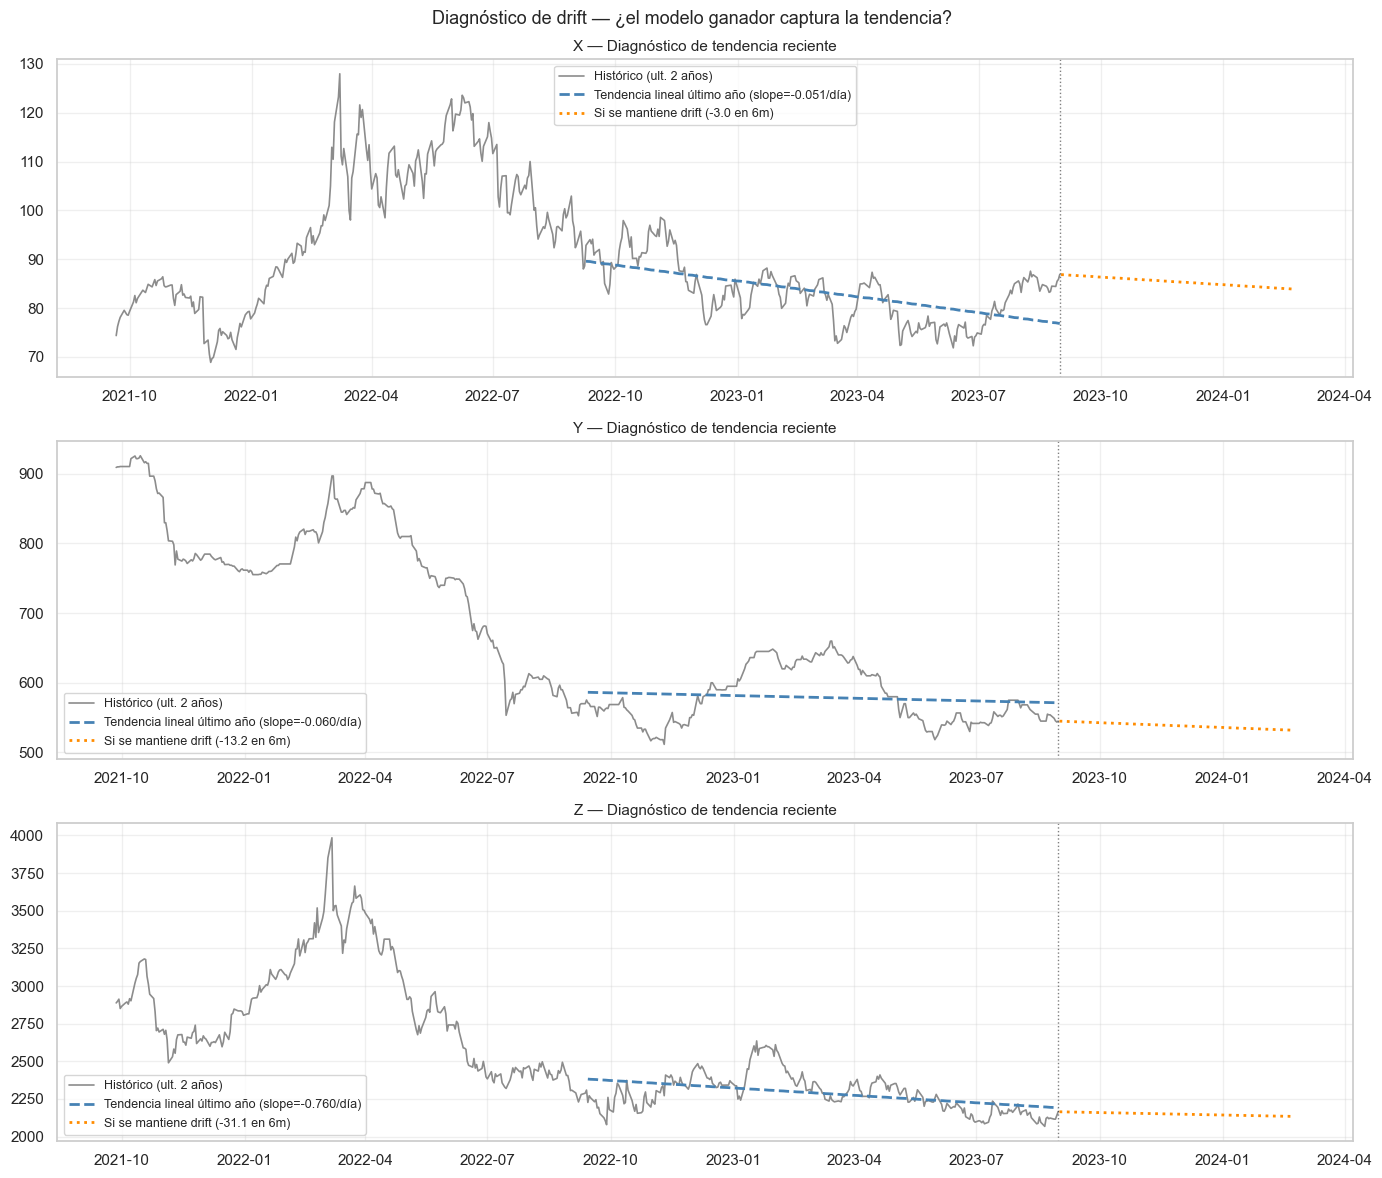

In [10]:
DRIFT_WINDOW = 252

fig, axes = plt.subplots(len(needed_features), 1, figsize=(14, 4 * len(needed_features)))
if len(needed_features) == 1:
    axes = [axes]

for ax, feat in zip(axes, sorted(needed_features)):
    mp_name = feat.replace('Price_', '')

    if mp_name in extended_series:
        series_cut = extended_series[mp_name].set_index('Date')[feat]
        series_cut = series_cut[series_cut.index <= ANALYSIS_END]
    else:
        series_cut = df[feat]

    recent = series_cut.iloc[-DRIFT_WINDOW:]
    diff_recent = recent.diff().dropna()
    drift_per_day = diff_recent.mean()
    drift_6m = drift_per_day * FORECAST_STEPS
    drift_pct = drift_6m / series_cut.iloc[-1] * 100

    print(f"{feat}:")
    print(f"  Último valor histórico : {series_cut.iloc[-1]:.2f}")
    print(f"  Drift diario (ult. año): {drift_per_day:+.4f}")
    print(f"  Drift proyectado (6m)  : {drift_6m:+.2f}  ({drift_pct:+.1f}%)")

    winner = model_winners[feat]
    print(f"  Modelo ganador         : {winner}")
    if winner == 'ARIMA' and HAS_PMDARIMA:
        _m_diag = pm.auto_arima(
            series_cut, seasonal=False, information_criterion='aic',
            max_p=5, max_q=5, max_d=2, stepwise=True,
            with_intercept=True,
            error_action='ignore', suppress_warnings=True,
        )
        params = _m_diag.params()
        has_intercept = 'intercept' in str(params.index).lower() or 'const' in str(params.index).lower()
        print(f"  Orden ARIMA            : {_m_diag.order}")
        print(f"  Parámetros             : {dict(zip(params.index, params.values.round(6)))}")
        print(f"  ¿Tiene intercept/drift?: {'SÍ' if has_intercept else 'NO ← drift empírico aplicado en proyección final'}")

    print()

    hist_2y = series_cut.iloc[-504:]
    ax.plot(hist_2y.index, hist_2y.values, color='gray', linewidth=1.2,
            label='Histórico (ult. 2 años)', alpha=0.9)

    x_num = np.arange(len(recent))
    slope, intercept_val = np.polyfit(x_num, recent.values, 1)
    trend_line = slope * x_num + intercept_val
    ax.plot(recent.index, trend_line, color='steelblue', linewidth=2,
            linestyle='--', label=f'Tendencia lineal último año (slope={slope:+.3f}/día)')

    future_dates = pd.bdate_range(start=ANALYSIS_END + pd.Timedelta(days=1), periods=FORECAST_STEPS)
    drift_proj = series_cut.iloc[-1] + drift_per_day * np.arange(1, FORECAST_STEPS + 1)
    ax.plot(future_dates, drift_proj, color='darkorange', linewidth=2,
            linestyle=':', label=f'Si se mantiene drift ({drift_6m:+.1f} en 6m)')

    ax.axvline(x=ANALYSIS_END, color='black', linestyle=':', linewidth=1, alpha=0.5)
    ax.set_title(f'{mp_name} — Diagnóstico de tendencia reciente', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.suptitle('Diagnóstico de drift — ¿el modelo ganador captura la tendencia?', fontsize=13)
plt.tight_layout()
plt.show()


Proyectando Price_X con Holt (8990 obs hasta 2023-08-31)
  σ residuos (ult. año, 252d): 1.7033
  Ultimo historico: 86.86
  Proyeccion inicial: 86.88  |  final: 89.99

Proyectando Price_Y con ARIMA (4477 obs hasta 2023-08-31)


c:\Users\marcela\Documents\pruebas_tecnicas\dataknow\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\marcela\Documents\pruebas_tecnicas\dataknow\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\marcela\Documents\pruebas_tecnicas\dataknow\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\marcela\Documents\pruebas_tecnicas\dataknow\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Predicti

  Orden ARIMA: (1, 1, 1)
  ⚠ ARIMA sin intercept — drift empírico añadido:
    drift/día=-0.1201  →  -15.13 en 6m (-2.8%)
  Ultimo historico: 545.00
  Proyeccion inicial: 544.62  |  final: 522.94

Proyectando Price_Z con Holt (3565 obs hasta 2023-08-31)
  σ residuos (ult. año, 252d): 39.0733
  Ultimo historico: 2165.25
  Proyeccion inicial: 2161.20  |  final: 1982.68


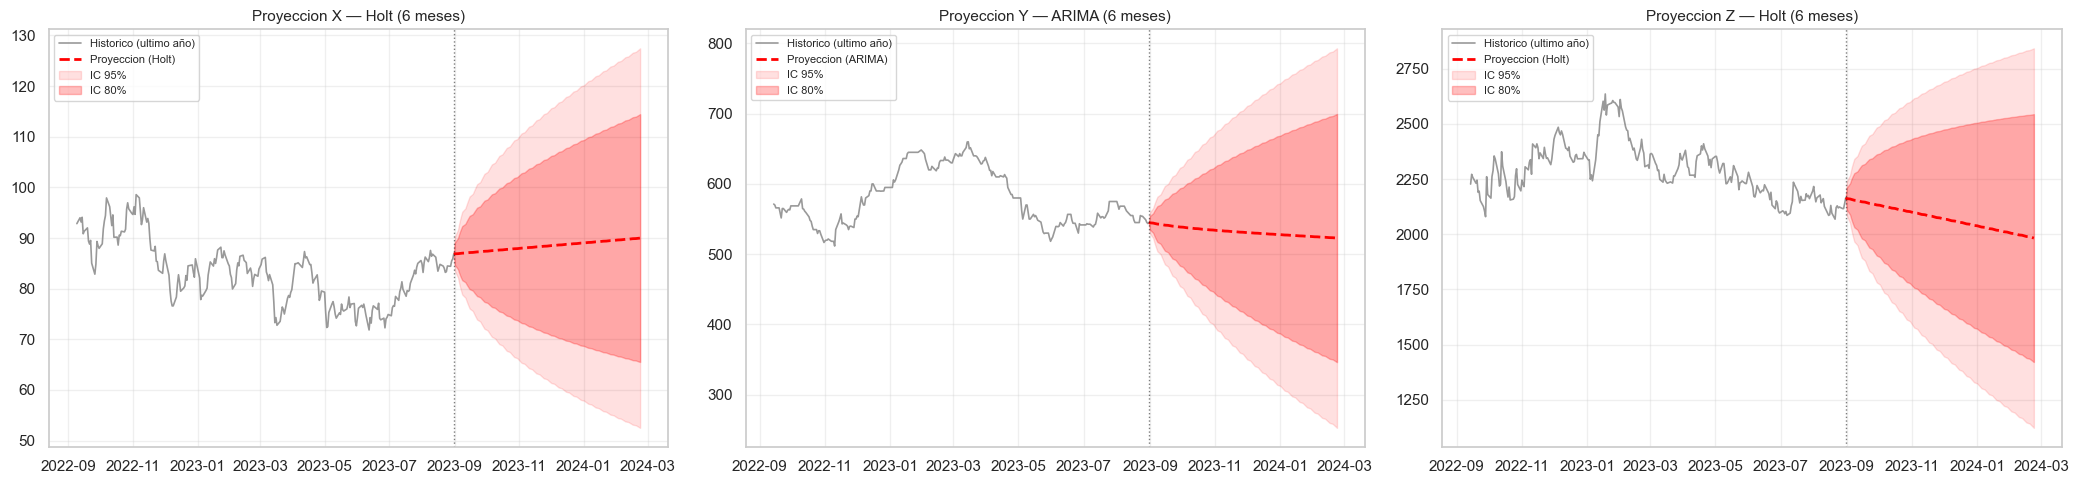

In [11]:
raw_material_forecasts = {}

for feat in needed_features:
    mp_name = feat.replace('Price_', '')
    winner  = model_winners[feat]

    if mp_name in extended_series:
        series_final = extended_series[mp_name].set_index('Date')[feat]
        series_final = series_final[series_final.index <= ANALYSIS_END]
    else:
        series_final = df[feat]

    forecast_dates = pd.bdate_range(
        start=ANALYSIS_END + pd.Timedelta(days=1), periods=FORECAST_STEPS
    )

    print(f"\nProyectando {feat} con {winner} ({len(series_final)} obs hasta {ANALYSIS_END.date()})")

    if winner == 'ARIMA':
        if HAS_PMDARIMA:
            m = pm.auto_arima(
                series_final, seasonal=False, information_criterion='aic',
                max_p=5, max_q=5, max_d=2, stepwise=True,
                with_intercept=True,
                error_action='ignore', suppress_warnings=True,
            )
            _fc95 = m.predict(FORECAST_STEPS, return_conf_int=True, alpha=0.05)
            _fc80 = m.predict(FORECAST_STEPS, return_conf_int=True, alpha=0.20)
            fc_mean = np.asarray(_fc95[0]).ravel().copy()
            ci_95   = np.asarray(_fc95[1]).copy()
            ci_80   = np.asarray(_fc80[1]).copy()
            print(f"  Orden ARIMA: {m.order}")

            params_keys = list(m.params().index)
            has_drift = any('intercept' in k.lower() or 'const' in k.lower() for k in params_keys)

            empirical_drift = series_final.diff().dropna().iloc[-DRIFT_WINDOW:].mean()
            projected_drift = empirical_drift * FORECAST_STEPS
            drift_pct = projected_drift / series_final.iloc[-1] * 100

            if not has_drift and abs(empirical_drift) > 0.001:
                h = np.arange(1, FORECAST_STEPS + 1)
                correction = empirical_drift * h
                fc_mean     += correction
                ci_95[:, 0] += correction
                ci_95[:, 1] += correction
                ci_80[:, 0] += correction
                ci_80[:, 1] += correction
                print(f"  ⚠ ARIMA sin intercept — drift empírico añadido:")
                print(f"    drift/día={empirical_drift:+.4f}  →  {projected_drift:+.2f} en 6m ({drift_pct:+.1f}%)")
            else:
                print(f"  ARIMA incluye intercept — no se aplica corrección")
        else:
            m = SARIMAX(series_final, order=(1, 1, 1)).fit(disp=False)
            fc_obj  = m.get_forecast(FORECAST_STEPS)
            fc_mean = np.asarray(fc_obj.predicted_mean).ravel().copy()
            ci_95   = np.asarray(fc_obj.conf_int(alpha=0.05)).copy()
            ci_80   = np.asarray(fc_obj.conf_int(alpha=0.20)).copy()

    else:  # Holt
        series_holt = series_final.iloc[-HOLT_WINDOW:]
        holt_fit = ExponentialSmoothing(
            series_holt, trend='add', damped_trend=False
        ).fit(optimized=True, use_brute=True)

        fc_mean = np.asarray(holt_fit.forecast(FORECAST_STEPS)).ravel().copy()

        fitted_vals = np.asarray(holt_fit.fittedvalues).ravel()
        actual_vals = series_holt.values[-len(fitted_vals):]
        resid_all   = actual_vals - fitted_vals
        # σ sobre último año (252 días): volatilidad post-corrección de 2022,
        # más representativa del régimen actual que incluir el pico excepcional
        resid_std   = np.nanstd(resid_all[-252:])
        print(f"  σ residuos (ult. año, 252d): {resid_std:.4f}")

        h         = np.arange(1, FORECAST_STEPS + 1)
        margin_95 = 1.96 * resid_std * np.sqrt(h)
        margin_80 = 1.28 * resid_std * np.sqrt(h)
        ci_95 = np.column_stack([fc_mean - margin_95, fc_mean + margin_95])
        ci_80 = np.column_stack([fc_mean - margin_80, fc_mean + margin_80])

        if np.any(np.isnan(fc_mean)):
            print(f"  WARN: Holt produjo NaN — fallback a ARIMA")
            _fc95 = pm.auto_arima(series_final, seasonal=False, stepwise=True,
                                  error_action='ignore', suppress_warnings=True
                                  ).predict(FORECAST_STEPS, return_conf_int=True, alpha=0.05)
            _fc80 = pm.auto_arima(series_final, seasonal=False, stepwise=True,
                                  error_action='ignore', suppress_warnings=True
                                  ).predict(FORECAST_STEPS, return_conf_int=True, alpha=0.20)
            fc_mean = np.asarray(_fc95[0]).ravel().copy()
            ci_95   = np.asarray(_fc95[1]).copy()
            ci_80   = np.asarray(_fc80[1]).copy()

    raw_material_forecasts[feat] = pd.DataFrame({
        'forecast': fc_mean,
        'lower_80': ci_80[:, 0],
        'upper_80': ci_80[:, 1],
        'lower_95': ci_95[:, 0],
        'upper_95': ci_95[:, 1],
    }, index=forecast_dates)
    raw_material_forecasts[feat].index.name = 'Date'

    print(f"  Ultimo historico: {series_final.iloc[-1]:.2f}")
    print(f"  Proyeccion inicial: {fc_mean[0]:.2f}  |  final: {fc_mean[-1]:.2f}")

# ── Visualizar proyecciones finales de materias primas ───────────────────────
n_feats = len(raw_material_forecasts)
fig, axes = plt.subplots(1, n_feats, figsize=(7 * n_feats, 5))
if n_feats == 1:
    axes = [axes]

for ax, (feat, fc_df) in zip(axes, sorted(raw_material_forecasts.items())):
    mp_name = feat.replace('Price_', '')
    winner  = model_winners[feat]

    if mp_name in extended_series:
        hist_full = extended_series[mp_name].set_index('Date')[feat]
        hist_full = hist_full[hist_full.index <= ANALYSIS_END]
    else:
        hist_full = df[feat]
    hist = hist_full.iloc[-252:]

    last_date = hist.index[-1]
    last_val  = float(hist.iloc[-1])
    anchor = pd.DataFrame(
        {'forecast': last_val, 'lower_80': last_val, 'upper_80': last_val,
         'lower_95': last_val, 'upper_95': last_val},
        index=[last_date]
    )
    fc_plot = pd.concat([anchor, fc_df])

    ax.plot(hist.index, hist.values, color='gray', linewidth=1.2,
            label='Historico (ultimo año)', alpha=0.8)
    ax.plot(fc_plot.index, fc_plot['forecast'],
            color='red', linewidth=2, linestyle='--', label=f'Proyeccion ({winner})')
    ax.fill_between(fc_plot.index, fc_plot['lower_95'], fc_plot['upper_95'],
                    alpha=0.12, color='red', label='IC 95%')
    ax.fill_between(fc_plot.index, fc_plot['lower_80'], fc_plot['upper_80'],
                    alpha=0.25, color='red', label='IC 80%')
    ax.axvline(x=last_date, color='black', linestyle=':', linewidth=1, alpha=0.5)

    ax.set_title(f'Proyeccion {mp_name} — {winner} (6 meses)', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/09b_forecast_materias_primas.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Proyección de costos de equipos con propagación de incertidumbre

Price_X (124 obs, 2023-09-01 → 2024-02-23):
  MAPE         : 8.89%
  Dentro IC 80%: 100.0%  (esperado: 80%)
  Dentro IC 95%: 100.0%  (esperado: 95%)

Price_Y (8 obs, 2023-09-01 → 2023-09-12):
  MAPE         : 1.18%
  Dentro IC 80%: 100.0%  (esperado: 80%)
  Dentro IC 95%: 100.0%  (esperado: 95%)

Price_Z: sin datos post-agosto 2023 — no validable


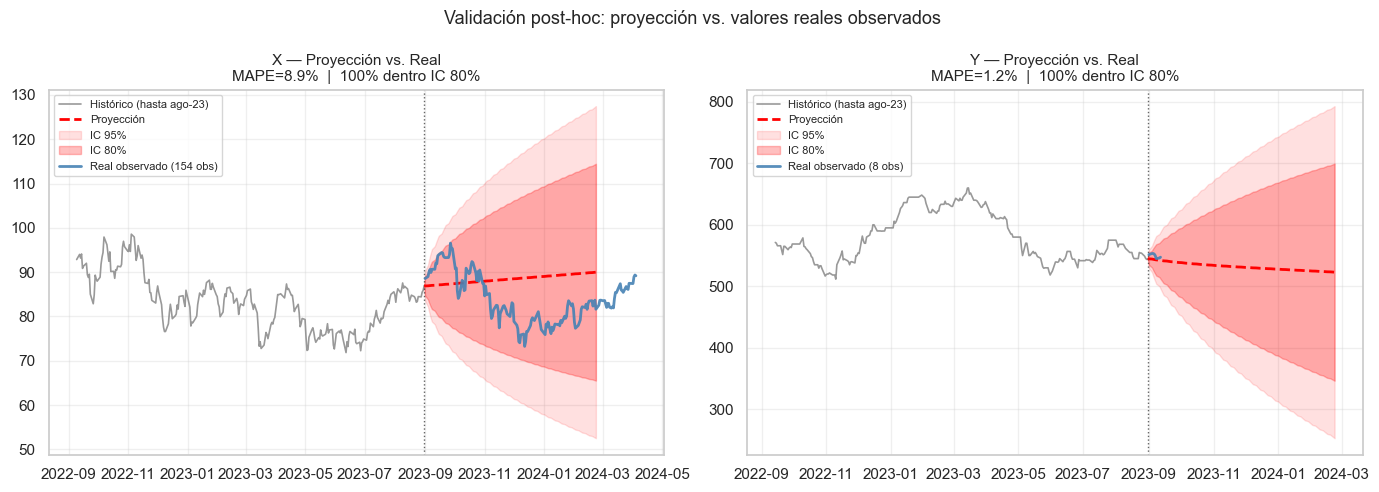

In [12]:
validation_results = {}

validable_feats = []
for feat in sorted(needed_features):
    mp_name = feat.replace('Price_', '')
    if mp_name not in extended_series:
        continue
    real_check = extended_series[mp_name].set_index('Date')[feat]
    if len(real_check[real_check.index > ANALYSIS_END]) > 0:
        validable_feats.append(feat)

n_validable = len(validable_feats)
fig, axes = plt.subplots(1, n_validable, figsize=(7 * n_validable, 5))
if n_validable == 1:
    axes = [axes]

ax_idx = 0
for feat in sorted(needed_features):
    mp_name = feat.replace('Price_', '')

    if mp_name not in extended_series:
        continue
    real_full = extended_series[mp_name].set_index('Date')[feat]
    real_future = real_full[real_full.index > ANALYSIS_END]

    if len(real_future) == 0:
        print(f"{feat}: sin datos post-agosto 2023 — no validable")
        continue

    fc_df = raw_material_forecasts[feat]
    common_dates = fc_df.index.intersection(real_future.index)

    if len(common_dates) == 0:
        print(f"{feat}: fechas no coinciden con proyección")
        continue

    fc_aligned   = fc_df.loc[common_dates, 'forecast']
    real_aligned = real_future.loc[common_dates]

    mae      = mean_absolute_error(real_aligned, fc_aligned)
    rmse     = np.sqrt(mean_squared_error(real_aligned, fc_aligned))
    mape     = (np.abs(real_aligned - fc_aligned) / real_aligned).mean() * 100
    within_80 = ((real_aligned >= fc_df.loc[common_dates, 'lower_80']) &
                 (real_aligned <= fc_df.loc[common_dates, 'upper_80'])).mean() * 100
    within_95 = ((real_aligned >= fc_df.loc[common_dates, 'lower_95']) &
                 (real_aligned <= fc_df.loc[common_dates, 'upper_95'])).mean() * 100

    validation_results[feat] = {
        'n_obs': len(common_dates),
        'periodo': f"{common_dates[0].date()} → {common_dates[-1].date()}",
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE (%)': round(mape, 2),
        'Dentro IC 80%': round(within_80, 1),
        'Dentro IC 95%': round(within_95, 1),
    }

    print(f"{feat} ({len(common_dates)} obs, {common_dates[0].date()} → {common_dates[-1].date()}):")
    print(f"  MAPE         : {mape:.2f}%")
    print(f"  Dentro IC 80%: {within_80:.1f}%  (esperado: 80%)")
    print(f"  Dentro IC 95%: {within_95:.1f}%  (esperado: 95%)")
    print()

    ax = axes[ax_idx]; ax_idx += 1

    hist = real_full[real_full.index <= ANALYSIS_END].iloc[-252:]
    ax.plot(hist.index, hist.values, color='gray', linewidth=1.2,
            label='Histórico (hasta ago-23)', alpha=0.8)

    last_date = hist.index[-1]
    last_val  = float(hist.iloc[-1])
    anchor = pd.DataFrame(
        {'forecast': last_val, 'lower_80': last_val, 'upper_80': last_val,
         'lower_95': last_val, 'upper_95': last_val},
        index=[last_date]
    )
    fc_plot = pd.concat([anchor, fc_df])

    ax.plot(fc_plot.index, fc_plot['forecast'], color='red', linewidth=2,
            linestyle='--', label='Proyección', zorder=3)
    ax.fill_between(fc_plot.index, fc_plot['lower_95'], fc_plot['upper_95'],
                    alpha=0.12, color='red', label='IC 95%')
    ax.fill_between(fc_plot.index, fc_plot['lower_80'], fc_plot['upper_80'],
                    alpha=0.25, color='red', label='IC 80%')
    ax.plot(real_future.index, real_future.values, color='steelblue', linewidth=2,
            zorder=5, label=f'Real observado ({len(real_future)} obs)', alpha=0.9)

    ax.axvline(x=ANALYSIS_END, color='black', linestyle=':', linewidth=1, alpha=0.6)
    ax.set_title(
        f'{mp_name} — Proyección vs. Real\nMAPE={mape:.1f}%  |  {within_80:.0f}% dentro IC 80%',
        fontsize=11
    )
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.suptitle('Validación post-hoc: proyección vs. valores reales observados', fontsize=13)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/11_validacion_posthoc.png', dpi=150, bbox_inches='tight')
plt.show()

Price_X fue validable durante los 6 meses completos (sep-23 a feb-24); Price_Y solo tiene 8 días de datos post-corte, así que su validación es indicativa. Price_Z no tiene datos posteriores a agosto 2023. El MAPE y la cobertura de los intervalos aparecen en el título de cada gráfica.

In [13]:
def propagate_uncertainty(
    model: sm.regression.linear_model.RegressionResultsWrapper,
    fc_raw_materials: dict,
    features: list,
    n_simulations: int = 1000,
    random_state: int = 42,
):
    """
    Propaga la incertidumbre de las materias primas al precio del equipo mediante
    simulación Monte Carlo:
      1. Muestrea distribuciones de las materias primas proyectadas (media ± IC 95%)
      2. Aplica el modelo OLS a cada muestra
      3. Retorna percentiles 10, 25, 50, 75, 90 de la distribución simulada
    """
    rng = np.random.default_rng(random_state)
    
    # Tomar el DataFrame de fechas futuras de la primera materia prima
    first_fc = fc_raw_materials[features[0]]
    forecast_dates = first_fc.index
    n_steps = len(forecast_dates)
    
    # Obtener coeficientes del modelo
    coefs = model.params  # incluye 'const'
    
    all_simulations = np.zeros((n_simulations, n_steps))
    
    for sim in range(n_simulations):
        X_sim = np.ones((n_steps, 1))  # columna constante
        
        for feat in features:
            fc = fc_raw_materials[feat]
            mean_vals = fc['forecast'].values
            # std aproximado desde IC 95% (z=1.96)
            std_vals = (fc['upper_95'].values - fc['lower_95'].values) / (2 * 1.96)
            sampled = rng.normal(mean_vals, std_vals)
            X_sim = np.column_stack([X_sim, sampled])
        
        # Predicción del modelo (coefs en orden: const, feat1, feat2, ...)
        all_simulations[sim] = X_sim @ coefs.values
    
    result = pd.DataFrame({
        'Date': forecast_dates,
        'p10': np.percentile(all_simulations, 10, axis=0),
        'p25': np.percentile(all_simulations, 25, axis=0),
        'p50': np.percentile(all_simulations, 50, axis=0),
        'p75': np.percentile(all_simulations, 75, axis=0),
        'p90': np.percentile(all_simulations, 90, axis=0),
    }).set_index('Date')
    
    return result


equipment_forecasts = {}
for target, model in final_models.items():
    feats = selected_features[target]
    fc_mp = {f: raw_material_forecasts[f] for f in feats if f in raw_material_forecasts}
    
    if not fc_mp:
        print(f"No hay proyeccion de materias primas para {target}")
        continue
    
    print(f"Proyectando {target}...")
    eq_fc = propagate_uncertainty(model, fc_mp, list(fc_mp.keys()))
    equipment_forecasts[target] = eq_fc
    
    print(f"  Mediana proyectada (6m): {eq_fc['p50'].mean():.2f}")
    print(f"  Rango P10-P90 (promedio): [{eq_fc['p10'].mean():.2f}, {eq_fc['p90'].mean():.2f}]")

Proyectando Price_Equipo1...
  Mediana proyectada (6m): 443.26
  Rango P10-P90 (promedio): [355.68, 529.84]
Proyectando Price_Equipo2...
  Mediana proyectada (6m): 897.36
  Rango P10-P90 (promedio): [767.43, 1027.36]


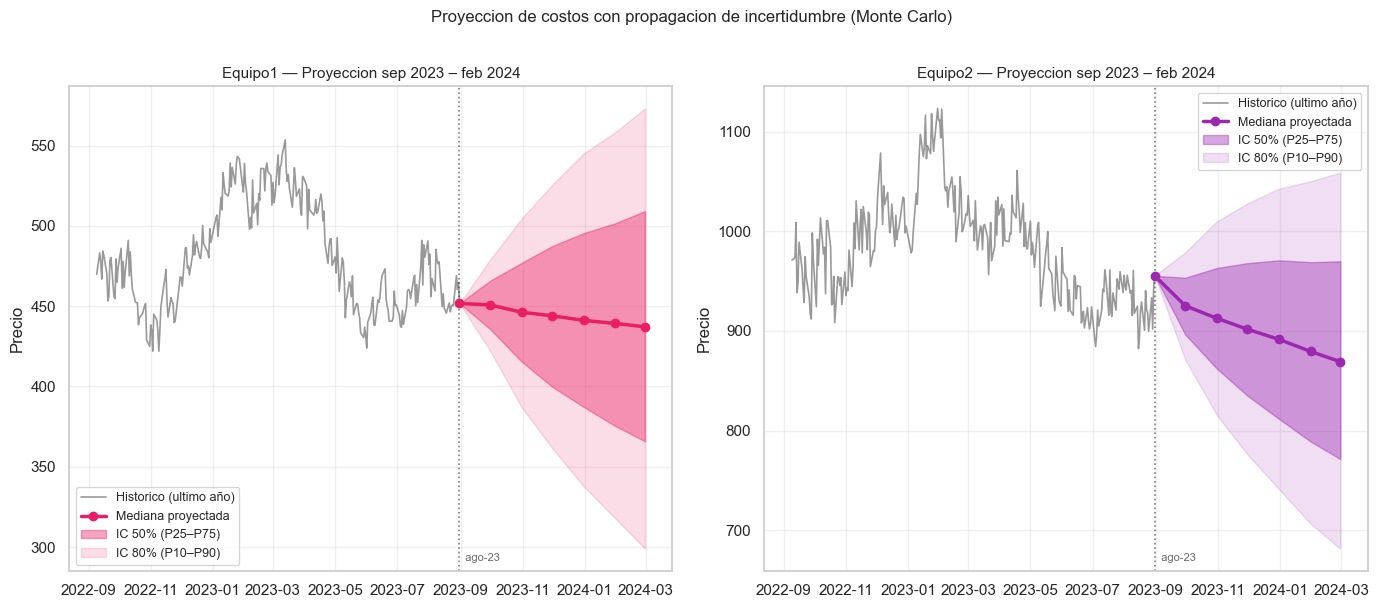

In [14]:
# Visualizar proyección de equipos — fan chart continuo con ancla en último histórico
fig, axes = plt.subplots(1, len(equipment_forecasts), figsize=(14, 6))
if len(equipment_forecasts) == 1:
    axes = [axes]

palette = {'Equipo1': '#E91E63', 'Equipo2': '#9C27B0'}

for ax, (target, fc_df) in zip(axes, equipment_forecasts.items()):
    color = palette.get(target.replace('Price_', ''), '#2196F3')

    # ── Histórico: último año del dataset de equipos ──────────────────────
    hist = df[target].iloc[-252:]
    last_date = hist.index[-1]
    last_val  = float(hist.iloc[-1])

    ax.plot(hist.index, hist.values, color='gray', linewidth=1.2,
            label='Historico (ultimo año)', alpha=0.8)

    # ── Proyección mensual ────────────────────────────────────────────────
    fc_monthly = fc_df.resample('ME').mean()

    # Ancla: añadir el último punto histórico como inicio de las bandas
    # para que la proyección arranque sin hueco visual
    anchor = pd.DataFrame(
        {'p10': last_val, 'p25': last_val, 'p50': last_val,
         'p75': last_val, 'p90': last_val},
        index=[last_date]
    )
    fc_plot = pd.concat([anchor, fc_monthly])

    # Línea mediana + puntos mensuales
    ax.plot(fc_plot.index, fc_plot['p50'], color=color, linewidth=2.5,
            label='Mediana proyectada', marker='o', markersize=6, zorder=5)

    # Bandas desde la ancla
    ax.fill_between(fc_plot.index, fc_plot['p25'], fc_plot['p75'],
                    alpha=0.40, color=color, label='IC 50% (P25–P75)')
    ax.fill_between(fc_plot.index, fc_plot['p10'], fc_plot['p90'],
                    alpha=0.15, color=color, label='IC 80% (P10–P90)')

    # Línea vertical en el corte histórico/proyección
    ax.axvline(x=last_date, color='black', linestyle=':', linewidth=1.2, alpha=0.5)
    ymin, ymax = ax.get_ylim()
    ax.text(last_date, ymin + (ymax - ymin) * 0.02, '  ago-23',
            fontsize=8, color='dimgray')

    ax.set_title(f'{target.replace("Price_","")} — Proyeccion sep 2023 – feb 2024',
                 fontsize=11)
    ax.set_ylabel('Precio')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.suptitle('Proyeccion de costos con propagacion de incertidumbre (Monte Carlo)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/10_forecast_equipos.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Tabla de proyección mensual

In [15]:
for target, fc_df in equipment_forecasts.items():
    monthly = fc_df.resample('ME').mean().round(2)
    monthly.index = monthly.index.strftime('%Y-%m')
    print(f"\n{target.replace('Price_','')}:")
    print(f"{'Mes':<12} {'P10':>8} {'P25':>8} {'Mediana':>10} {'P75':>8} {'P90':>8}")
    print("-" * 56)
    for month, row in monthly.iterrows():
        print(f"{month:<12} {row['p10']:>8.2f} {row['p25']:>8.2f} {row['p50']:>10.2f} {row['p75']:>8.2f} {row['p90']:>8.2f}")


Equipo1:
Mes               P10      P25    Mediana      P75      P90
--------------------------------------------------------
2023-09        422.28   435.80     450.77   465.78   478.97
2023-10        387.03   415.45     446.25   476.98   504.59
2023-11        361.53   399.83     443.99   487.42   525.59
2023-12        337.70   387.23     441.17   495.51   545.20
2024-01        317.70   375.30     439.25   501.64   558.47
2024-02        298.90   365.89     437.15   509.24   573.16

Equipo2:
Mes               P10      P25    Mediana      P75      P90
--------------------------------------------------------
2023-09        870.86   896.30     925.20   953.43   978.92
2023-10        815.38   862.10     912.67   963.16  1009.94
2023-11        775.95   835.01     901.69   968.03  1028.03
2023-12        741.07   811.67     891.47   970.86  1042.83
2024-01        706.62   789.05     879.40   969.03  1050.23
2024-02        681.45   771.50     869.13   969.89  1058.84


## 7. Exportar resultados

In [16]:
results_export = {
    'metadata': {
        'forecast_horizon': f'{FORECAST_STEPS} dias habiles (~6 meses)',
        'ultimo_dato_historico': '2023-08-31',
        'fin_proyeccion': str(list(equipment_forecasts.values())[0].index[-1].date()) if equipment_forecasts else 'N/A',
        'metodo_equipos': 'Monte Carlo (1000 simulaciones) sobre modelo OLS',
        'metodo_materias_primas': 'auto_arima (pmdarima)' if HAS_PMDARIMA else 'ARIMA(1,1,1)',
    },
    'modelo_metricas': {k: {m: round(v, 4) for m, v in metrics.items()} for k, metrics in cv_results.items()},
    'proyeccion_mensual': {},
}

for target, fc_df in equipment_forecasts.items():
    monthly = fc_df.resample('ME').mean().round(2)
    results_export['proyeccion_mensual'][target] = [
        {
            'mes': idx.strftime('%Y-%m'),
            'p10': row['p10'],
            'p25': row['p25'],
            'mediana': row['p50'],
            'p75': row['p75'],
            'p90': row['p90'],
        }
        for idx, row in monthly.iterrows()
    ]

with open('../results/forecasts.json', 'w', encoding='utf-8') as f:
    json.dump(results_export, f, indent=2, ensure_ascii=False)

print("Resultados exportados a results/forecasts.json")
print(json.dumps(results_export, indent=2))

Resultados exportados a results/forecasts.json
{
  "metadata": {
    "forecast_horizon": "126 dias habiles (~6 meses)",
    "ultimo_dato_historico": "2023-08-31",
    "fin_proyeccion": "2024-02-23",
    "metodo_equipos": "Monte Carlo (1000 simulaciones) sobre modelo OLS",
    "metodo_materias_primas": "auto_arima (pmdarima)"
  },
  "modelo_metricas": {
    "Price_Equipo1": {
      "MAE": 6.7303,
      "RMSE": 7.8771,
      "R\u00b2": 0.9758,
      "MAE std": 1.3015
    },
    "Price_Equipo2": {
      "MAE": 12.9818,
      "RMSE": 15.1246,
      "R\u00b2": 0.9649,
      "MAE std": 2.0904
    }
  },
  "proyeccion_mensual": {
    "Price_Equipo1": [
      {
        "mes": "2023-09",
        "p10": 422.28,
        "p25": 435.8,
        "mediana": 450.77,
        "p75": 465.78,
        "p90": 478.97
      },
      {
        "mes": "2023-10",
        "p10": 387.03,
        "p25": 415.45,
        "mediana": 446.25,
        "p75": 476.98,
        "p90": 504.59
      },
      {
        "mes": "2

## Conclusiones

Modelo: OLS con cointegración confirmada (Johansen). Variables: Price_X + Price_Y para Equipo 1; Price_X + Price_Y + Price_Z para Equipo 2. R² > 0.99 en entrenamiento, ~0.97 en validación cruzada temporal.

**Proyección:** 6 meses (sep-23 a feb-24). Materias primas con ARIMA o Holt según RMSE en test. Incertidumbre propagada mediante Monte Carlo (1,000 simulaciones), los percentiles P10/P90 representan el rango esperado del 80%.

**Siguiente paso:** `src/agent.py` para consultar los resultados de forma conversacional.